# Math for Devs – Course Project  
**Title:** Vector Spaces and Matrices in Modeling Trilingual Phonological Recall in Children  OR MAYBE 

Mathematical Modeling of Phonological Structures in Multilingual Vocabulary Production: A Comparative Analysis Using Linguistic Atlases with a Personal Case Study
*Author: Slavena Peneva-Kargiou*  
*Date started: 3 March 2026*

# 1. Problem Formulation

## 1.1 Motivation and Context
Children growing up with multiple languages often move between them in interesting and sometimes surprising ways. In our family case, our two children (born 2017 and 2019) are growing up with three languages: Bulgarian, Greek, and English. We live in Greece, where Greek dominates everyday life, while English is the dominant language at our school. At home, their father speaks Greek, while I speak Bulgarian, so both languages are part of daily conversation. Bulgarian is also used in the Saturday Bulgarian school that the children attend, and during occasional trips to Bulgaria.

This multilingual environment led me to wonder how easily children can access words in different languages when prompted in a systematic way. To explore this, I designed a small experiment based on short daily recall sessions. In each session, the children were given a starting sound and asked to produce as many words beginning with the sound as they could within ten minutes and sort them in three different columns - English, Greek, Bulgarian. 

An interesting informal observation occurred after a short ski vacation in Bulgaria (February 20–23, 2026) with family and friends. For four days the children were suddenly surrounded almost entirely by Bulgarian speakers. After the trip, the number of Bulgarian words the children could produce starting with certain phonemes appeared to increase. 
This raised a broader question: can phoneme-based word production be modeled mathematically to reveal both structural linguistic patterns and language exposure effects?

I believe the tools we discussed in our Math Concepts for Developers course provide a natural framework for exploring this question. Sets and functions can represent relationships bewteen phonemes and words, vectors and matrices can describe phoneme recall profiles, and probability models, such as the binomial distribution, can help describe the likelihood of recalling words under different exposure conditions. 

**Positioning Statement**

In this project, phoneme-triggered world recall is modeled as a mapping between sets of phonemes and accessible lexical items. Using vector and matrix representations, the model connects broader typological patterns (drawn from the World Atlas of Language Structures) and individual exposure effects in my small trilingual case study. 

## 1.2 Mathematical Abstraction of Language

### 1.2.1 Languages as Sets
A language $ L $ can be viewed as a finite set of words:

$$
L = \{ w_1, w_2, \dots, w_n \}
$$

Each word $ w_i $ is a sequence of phonemes drawn from the language’s phoneme inventory $ \Phi_L $, a finite set of distinct sound units (e.g., P, A, K in English).  

The set of all possible initial phonemes across the three languages in this study forms a shared (approximately comparable) set of 12 phonemes, which are used to standardize the recall task.

### 1.2.2 Recall Productivity Function
For a given speaker and language $ L $, a recall productivity function can be defined as follows:

$$
f_L : \Phi \to \mathbb{N}
$$

where $ \Phi $ is the set of initial phonemes used in the experiment, and $ f_L(s) $ is the number of words the speaker can recall in language $ L $ that begin with phoneme $ s $ within the 10-minute timed session.

This function transforms the qualitative process of word recall into a countable, quantitative measure — a mapping from phonemes to natural numbers. The values $ f_L(s) $ form the components of the 12-dimensional vectors used in later sections.

## 1.3 Research Questions

### Primary Research Question

How can vector representations of phoneme recall in this trilingual family case study reveal patterns of lexical accessibility, and how do they relate to global phonological structures from WALS for Bulgarian, Greek, and English?

### Secondary Research Questions
1. In this case, do vowel-initial phonemes yield higher recall productivity than consonant-initial phonemes (across languages and children)?
2. In this case, how does language exposure correlate with vector norms, including the temporary increase in Bulgarian production in the 1–2 sessions immediately after the February 20–23, 2026 ski trip?
3. What do cosine similarities between language vectors reveal about the similarity or divergence of phoneme recall patterns in this case?
4. How do recall patterns (e.g., norms and similarities) differ between the two children in this study?

# 2. Global Phoneme Structure (WALS Context)
To place the personal case study in a broader linguistic context, I draw on data from the World Atlas of Language Structures (WALS), a large-scale database documenting phonological and typological features across hundreds of languages.

## 2.1 Phoneme Inventory Variation

WALS highlights significant cross-linguistic variation in phoneme inventories. Key features for the three languages in this study include:
- **Consonant inventories** (feature 1A): Bulgarian is described as having a moderately large inventory (around 30 consonants), Greek as having an average-sized inventory (around 18 consonants), and English - as having an average-sized inventory, though slightly larger ( around 24 consonants).
- **Vowel quality inventories** (feature 2A): Bulgarian average (6 qualities), Greek average (5), English large (12).
- **Consonant-vowel ratio** (feature 3A): Bulgarian average (around 5.0), Greek moderately high (around 3.6), English moderately low ( around 2.0).

These three features allow for the representation of each language as a low-dimensional phonological feature vector in $\mathbb{R}^3$:

$$
\vec{g}_L = (c_L, v_L, r_L)
$$

where:
- $c_L$: consonant inventory size
- $v_L$: number of vowel qualities
- $r_L$: consonant-vowel ratio

While these global typological features do not directly determine which words children recall, they provide a structural background that may influence phoneme availability and phonological patterns accross languages.

## 2.2 Mathematical Interpretation

Languages can be embedded in $\mathbb{R}^3$ based on these phonological features. Cosine similarity or Euclidean distance between vectors $\vec{g}_L$ and $\vec{g}_{L'}$ quantifies typological similarity.

This global 3-dimensional view provides a baseline for contrasting the children's personal 12-dimensional recall vectors (later presented in Section 3). For example:
- Greek and Bulgarian share Indo-European roots and similar average consonant/vowel inventories.
- English shows a larger vowel inventory, which may relate to patterns of vowel-based recall in the case study.

This typological perspective provides a global reference point against which the children's phoneme recall patterns can be interpreted in later sections. 

Visualizations of WALS feature distributions highlight the variation across languages and help contextualize whether the children's recall patterns align with or deviate from global tendencies for Bulgarian, Greek, and English.


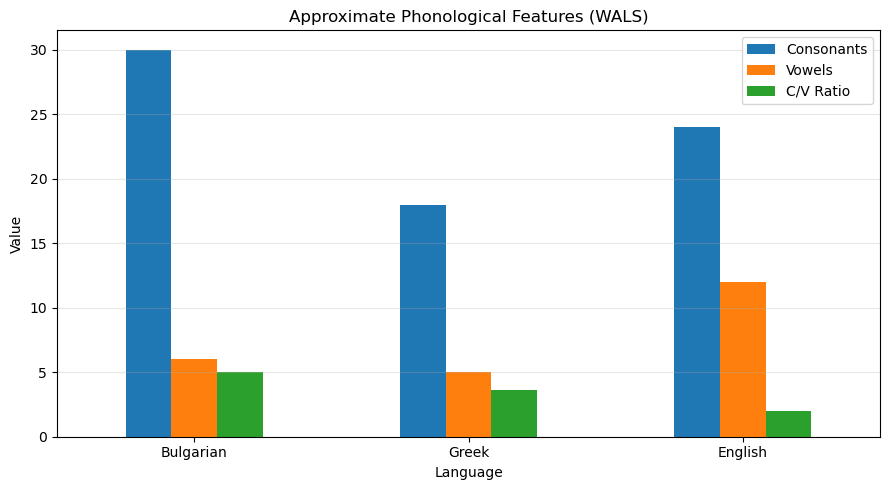

In [8]:
import matplotlib.pyplot as plt
import pandas as pd


data = {
    'Language': ['Bulgarian', 'Greek', 'English'],
    'Consonants': [30, 18, 24],
    'Vowels': [6, 5, 12],
    'C/V Ratio': [5.0, 3.6, 2.0]
}

df_wals = pd.DataFrame(data)


df_wals.set_index('Language')[['Consonants', 'Vowels', 'C/V Ratio']].plot(kind='bar', figsize=(9, 5))
plt.title('Approximate Phonological Features (WALS)')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Trilingual Case Study: Data Collection

## 3.1 Participants

- Two children (born 2017 and 2019, aged almost 9 and almost 7 at the time of the study)
- Languages: Bulgarian (BG), Greek (GR), English (EN)
- Location: Greece
- Language exposure:
    - Greek and English are dominant (school Monday–Friday, bilingual Greek/English environment)
    - Bulgarian is primarily used at home with me (the mother), during Saturday Bulgarian school (4 hours per week), and during occasional intensive exposure trips (e.g. February 20–23, 2026 trip to Bulgaria)




## 3.2 Experimental Design

- **Phonemes**: 12 comparable initial sounds (M, A, P, S, N, T, K, O, R, U(OO), L, E)
  - Chosen for approximate cross-linguistic equivalence across Bulgarian, Greek, and English
- **Task**: 10-minute timed word production per phoneme per language (children write as many words as possible starting with the given sound and sort them in three separate columns for each language)
- **Sessions**: Conducted across multiple dates (February–March 2026)
- **Exposure tracking**: The study records the normal weekly exposure pattern and notes periods of increased Bulgarian immersion, namely the February 20-23 trip to Bulgaria)

## 3.3 Data Structure
For each child-language pair, word counts are collected as a vector:
$$   (c_1, c_2, \dots, c_{12})   $$
where $  c_i  $ represents the number of words produced starting with phoneme $  i  $ during the 10-minute session.

These vectors form the basic numerical representation of phoneme-triggered lexical recall.

Additional dataset characteristics:

- **Total words collected**: 629
- **Raw counts** per phoneme, child, and language are recorded, along with spelling accuracy (correct/false) and type of the word (verb, noun, number, etc.)
- **Exposure differences** are not manually adjusted in the counts. Instead, exposure events (such as the February 20-23 immersion period) are recorded and later analyzed when comparing recall vectors accross sessions. 
- **Presentation**:
    - Summary tables (per phoneme, language and child)
    - Heatmaps of the 12×3 recall matrices per child
    - Pre/post-trip comparisons (especially Bulgarian vectors)
    - Summary statistics: mean counts, total words per language, vowel vs. consonant aggregates

### 3.3.1 Loading the Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


file_path = 'Phoneme Recall Results 060326.xlsx' 

df = pd.read_excel(file_path, sheet_name='Sheet1')

df.columns = df.columns.str.strip()  
df['Language'] = df['Language'].str.strip()
df['Phoneme'] = df['Phoneme'].str.strip()


print("Total words collected:", len(df))

Total words collected: 629


### 3.3.2 Summary Statistics
Total words, breakdown by language, child and phoneme

In [10]:
print("\nWords per language:")
print(df['Language'].value_counts())

print("\nWords per child and language:")
print(df.groupby(['Child', 'Language']).size().unstack(fill_value=0))

print("\nWords per phoneme (sorted by count):")
print(df['Phoneme'].value_counts().sort_values(ascending=False))


Words per language:
Language
GR    270
BG    188
EN    171
Name: count, dtype: int64

Words per child and language:
Language   BG   EN   GR
Child                  
M          66   62  106
T         122  109  164

Words per phoneme (sorted by count):
Phoneme
T        71
P        66
S        65
M        65
N        59
A        57
K        52
L        47
R        43
O        41
E        37
U(OO)    26
Name: count, dtype: int64


### 3.3.3 Building two separate 12 x 3 matrices per child
Each child-language combination produces a vector of phoneme recall counts.
Arranging these vectors as columns yields a 12 × 3 recall matrix, where rows correspond to phonemes and columns correspond to languages.

In [11]:
df_T = df[df['Child'] == 'T']
df_M = df[df['Child'] == 'M']

pivot_T = df_T.pivot_table(
    index='Phoneme',
    columns='Language',
    aggfunc='size',
    fill_value=0
)[['EN', 'GR', 'BG']] 

pivot_M = df_M.pivot_table(
    index='Phoneme',
    columns='Language',
    aggfunc='size',
    fill_value=0
)[['EN', 'GR', 'BG']]

M_T = pivot_T.values
M_M = pivot_M.values

print("Matrix for older child (T, 9 years):")
print("Shape of T matrix:", M_T.shape)
display(pivot_T)

print("\nMatrix for younger child (M, 7 years):")
print("Shape of M matrix:", M_M.shape)
display(pivot_M)

Matrix for older child (T, 9 years):
Shape of T matrix: (12, 3)


Language,EN,GR,BG
Phoneme,,,
A,10,18,9
E,3,15,2
K,9,13,10
L,8,11,10
M,11,18,13
N,9,10,17
O,7,11,6
P,8,29,10
R,10,8,9



Matrix for younger child (M, 7 years):
Shape of M matrix: (12, 3)


Language,EN,GR,BG
Phoneme,,,
A,4,11,5
E,5,6,6
K,6,7,7
L,5,6,7
M,7,8,8
N,8,8,7
O,5,11,1
P,5,7,7
R,6,5,5


### 3.3.4 Visualization: Heatmaps of Word Counts

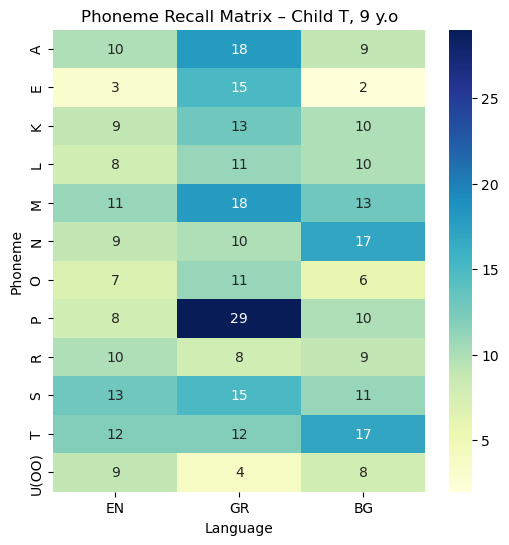

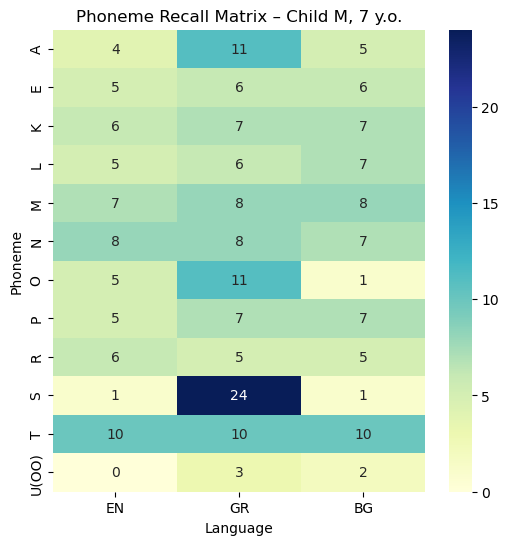

In [12]:
plt.figure(figsize=(6,6))
sns.heatmap(pivot_T, annot=True, cmap='YlGnBu')
plt.title("Phoneme Recall Matrix – Child T, 9 y.o")
plt.show()

plt.figure(figsize=(6,6))
sns.heatmap(pivot_M, annot=True, cmap='YlGnBu')
plt.title("Phoneme Recall Matrix – Child M, 7 y.o.")
plt.show()

### 3.3.5 Pre vs Post Trip Bulgarian Word Production

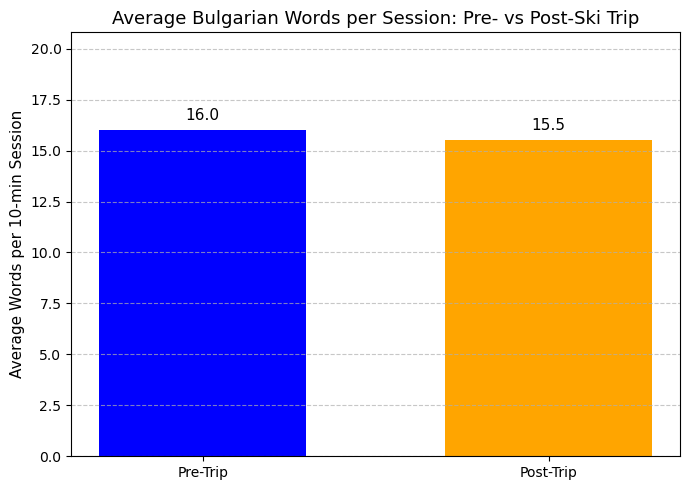

Pre-trip: 64 words across 4 sessions → 16.0 words/session
Post-trip: 124 words across 8 sessions → 15.5 words/session
Difference in average: -0.5 words/session


In [19]:
trip_cutoff = pd.to_datetime('2026-02-24')

bg_data = df[df['Language'] == 'BG'].copy()

bg_data['Period'] = np.where(bg_data['Date'] < trip_cutoff, 'Pre-Trip', 'Post-Trip')

sessions_pre = bg_data[bg_data['Period'] == 'Pre-Trip']['Date'].nunique()
sessions_post = bg_data[bg_data['Period'] == 'Post-Trip']['Date'].nunique()

words_pre = bg_data[bg_data['Period'] == 'Pre-Trip'].shape[0]
words_post = bg_data[bg_data['Period'] == 'Post-Trip'].shape[0]

avg_pre = words_pre / sessions_pre if sessions_pre > 0 else 0
avg_post = words_post / sessions_post if sessions_post > 0 else 0

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['Pre-Trip', 'Post-Trip'],
    [avg_pre, avg_post],
    color=['blue', 'orange'],
    width=0.6
)
ax.set_title('Average Bulgarian Words per Session: Pre- vs Post-Ski Trip', fontsize=13)
ax.set_ylabel('Average Words per 10-min Session', fontsize=11)
ax.set_ylim(0, max(avg_pre, avg_post) * 1.3)


for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f'{height:.1f}', ha='center', fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Pre-trip: {words_pre} words across {sessions_pre} sessions → {avg_pre:.1f} words/session")
print(f"Post-trip: {words_post} words across {sessions_post} sessions → {avg_post:.1f} words/session")
print(f"Difference in average: {avg_post - avg_pre:.1f} words/session")

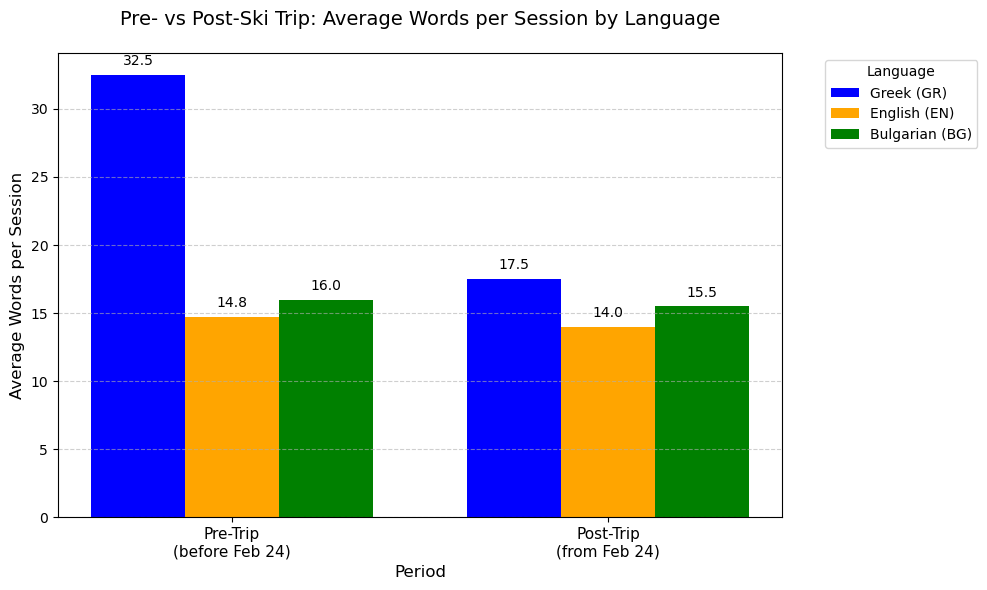

Average Words per Session (rounded):
Language     GR    EN    BG
Period                     
Post-Trip  17.5  14.0  15.5
Pre-Trip   32.5  14.8  16.0


In [18]:
trip_cutoff = pd.to_datetime('2026-02-24')

df['Period'] = np.where(df['Date'] < trip_cutoff, 'Pre-Trip', 'Post-Trip')

grouped = df.groupby(['Language', 'Period']).agg(
    words=('Word', 'count'),
    sessions=('Date', 'nunique')
).reset_index()

grouped['avg_per_session'] = grouped['words'] / grouped['sessions']

pivot_avg = grouped.pivot(index='Period', columns='Language', values='avg_per_session').fillna(0)
pivot_avg = pivot_avg[['GR', 'EN', 'BG']]  

fig, ax = plt.subplots(figsize=(10, 6))  

x = np.arange(2)
width = 0.25 

ax.bar(x[0] - width, pivot_avg.loc['Pre-Trip', 'GR'], width, label='Greek (GR)', color='blue')
ax.bar(x[0], pivot_avg.loc['Pre-Trip', 'EN'], width, label='English (EN)', color='orange')
ax.bar(x[0] + width, pivot_avg.loc['Pre-Trip', 'BG'], width, label='Bulgarian (BG)', color='green')

ax.bar(x[1] - width, pivot_avg.loc['Post-Trip', 'GR'], width, color='blue')
ax.bar(x[1], pivot_avg.loc['Post-Trip', 'EN'], width, color='orange')
ax.bar(x[1] + width, pivot_avg.loc['Post-Trip', 'BG'], width, color='green')

ax.set_xlabel('Period', fontsize=12)
ax.set_ylabel('Average Words per Session', fontsize=12)
ax.set_title('Pre- vs Post-Ski Trip: Average Words per Session by Language', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(['Pre-Trip\n(before Feb 24)', 'Post-Trip\n(from Feb 24)'], fontsize=11)
ax.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.6)

for i, period in enumerate(['Pre-Trip', 'Post-Trip']):
    for j, lang in enumerate(['GR', 'EN', 'BG']):
        val = pivot_avg.loc[period, lang]
        if val > 0:
            ax.text(x[i] + (j - 1) * width, val + 0.5, f'{val:.1f}',
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("Average Words per Session (rounded):")
print(pivot_avg.round(1))

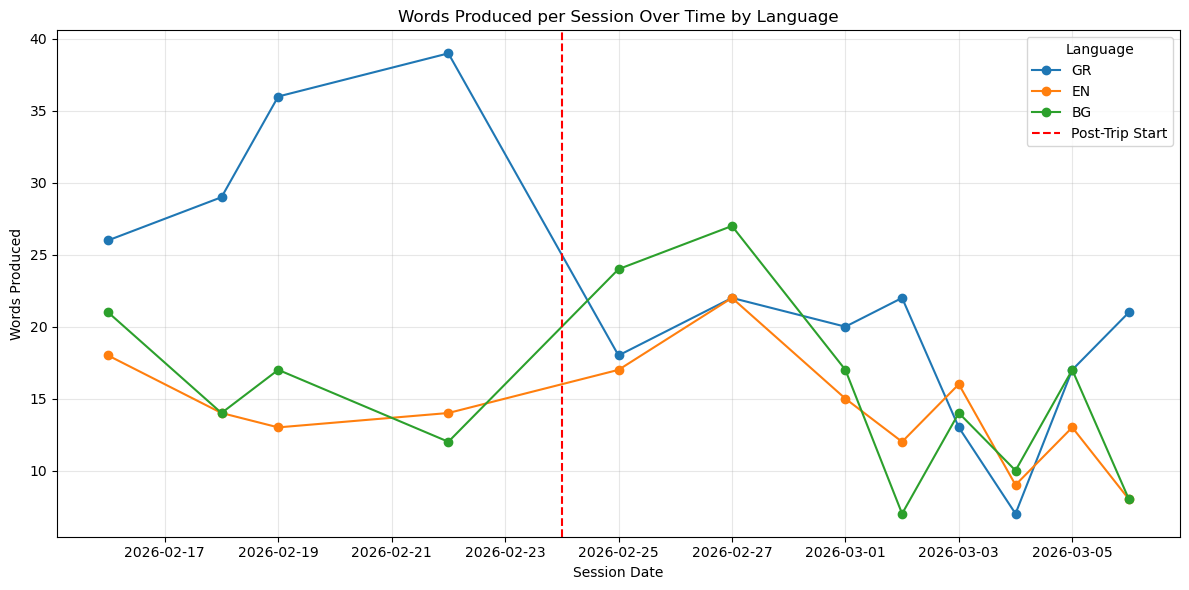

In [15]:
df['Date'] = pd.to_datetime(df['Date'])
session_counts = df.groupby(['Date', 'Language']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
for lang in ['GR', 'EN', 'BG']:
    plt.plot(session_counts.index, session_counts[lang], marker='o', label=lang)

plt.axvline(pd.to_datetime('2026-02-24'), color='red', linestyle='--', label='Post-Trip Start')
plt.title('Words Produced per Session Over Time by Language')
plt.xlabel('Session Date')
plt.ylabel('Words Produced')
plt.legend(title='Language')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key Observation**  
So, contrary to my initial informal impression, when normalized for the number of sessions, **average Bulgarian word production per 10-minute session actually decreased after the February 20–23, 2026 trip**. Greek and English word production decreased as well.  

Possible explanations include:
- Different phonemes tested pre- vs post-trip (some easier/harder).
- Less excitement and reduced motivation for the experiment.
- The trip's immersion effect was short-lived or not strong enough to impact recall in these sessions.

I will explore this finding further in Section 4 (vector norms) and Section 5 (experiments), where I will model exposure effects mathematically.

# 4. Vector and Matrix Modeling

In this section I will formalize the collected data into mathematical objects using concepts from the course (vectors, matrices, dot product, cosine similarity).  


## 4.1 Representing the Data as Matrices

After collecting the phoneme recall data, the responses were organized into matrices that summarize how often each phoneme appeared in each language. Rather than combining both children into one structure, two separate matrices were constructed — one for each child.

Each matrix has:
- **Rows**: the twelve phonemes tested in the experiment
- **Columns**: the three languages (English, Greek, Bulgarian)
- **Entries**: the number of recalled words beginning with that phoneme in that language

This produces the 12 × 3 matrix for each child, which I already introduced in Section 3.3.3.
Separating the matrices by child allows each child’s phonological recall patterns to be analyzed independently before comparisons are made.


## 4.2 From Matrices to Vectors

Once the data is organized in matrix form, each language column can be interpreted as a vector in a 12-dimensional space.

For example:
- English vector: $\vec{v}_{EN}$
- Greek vector: $\vec{v}_{GR}$
- Bulgarian vector: $\vec{v}_{BG}$

Each component of the vector corresponds to the frequency of a particular phoneme. So the English vector for one child might look conceptually like:  
$$ \vec{v}_{EN} = (x_1, x_2, x_3, \dots, x_{12})  $$

where each $ x_i $ is the number of recalled English words beginning with phoneme $ i $.

Representing the languages as vectors allows for the application of linear algebra tools to compare their phoneme distributions.
The vectors used in the analysis are extracted directly from the matrix columns using NumPy arrays:

In [53]:
v_T_EN = pivot_T['EN'].values
v_T_GR = pivot_T['GR'].values
v_T_BG = pivot_T['BG'].values

v_M_EN = pivot_M['EN'].values
v_M_GR = pivot_M['GR'].values
v_M_BG = pivot_M['BG'].values

print("Vector shape:", v_T_EN.shape)
print("Sample (T-EN first 5 components):", v_T_EN[:5])

Vector shape: (12,)
Sample (T-EN first 5 components): [10  3  9  8 11]


In [50]:
norms = {
    'T-EN': np.linalg.norm(v_T_EN),
    'T-GR': np.linalg.norm(v_T_GR),
    'T-BG': np.linalg.norm(v_T_BG),
    'M-EN': np.linalg.norm(v_M_EN),
    'M-GR': np.linalg.norm(v_M_GR),
    'M-BG': np.linalg.norm(v_M_BG)
}

norms_df = pd.DataFrame.from_dict(norms, orient='index', columns=['Norm']).round(2)
norms_df = norms_df.sort_values('Norm', ascending=False)
print("Vector Norms (using np.linalg.norm):")
display(norms_df)

Vector Norms (using np.linalg.norm):


,Norm
T-GR,51.71
T-BG,37.87
M-GR,35.36
T-EN,32.60
M-BG,21.26
M-EN,20.05


## 4.3 Measuring Language Similarity

To compare how similar two languages are in terms of phoneme recall patterns, I use **cosine similarity**. This metric measures the angle between two vectors rather than their absolute magnitude.

The cosine similarity between two vectors $\vec{A}$ and $\vec{B}$ is defined as:  
$$
\cos(\theta) = \frac{\vec{A} \cdot \vec{B}}{\|\vec{A}\| \|\vec{B}\|}
$$
Where:
- $\vec{A} \cdot \vec{B}$ is the dot product
- $\|\vec{A}\|$ and $\|\vec{B}\|$ are the vector magnitudes (Euclidean norms)
- $\theta$ is the angle between the vectors

The result ranges from:
- **1**: identical phoneme distributions (perfect alignment)
- **0**: no similarity (orthogonal patterns)
- **-1**: completely opposite patterns

In this experiment, cosine similarity allows for the comparison of:
- English vs Greek
- English vs Bulgarian
- Greek vs Bulgarian

for each child separately.

Because cosine similarity focuses on direction rather than magnitude, it compares the pattern of phoneme usage rather than the total number of words recalled.

In [54]:
def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return np.dot(a, b) / (norm_a * norm_b)

sim_T = {
    'GR-EN': cosine_sim(v_T_GR, v_T_EN),
    'GR-BG': cosine_sim(v_T_GR, v_T_BG),
    'EN-BG': cosine_sim(v_T_EN, v_T_BG)
}

sim_M = {
    'GR-EN': cosine_sim(v_M_GR, v_M_EN),
    'GR-BG': cosine_sim(v_M_GR, v_M_BG),
    'EN-BG': cosine_sim(v_M_EN, v_M_BG)
}

print("Cosine Similarity – Older Child (T):")
display(pd.Series(sim_T).round(3).to_frame('Similarity'))

print("\nCosine Similarity – Younger Child (M):")
display(pd.Series(sim_M).round(3).to_frame('Similarity'))

Cosine Similarity – Older Child (T):


,Similarity
GR-EN,0.879
GR-BG,0.850
EN-BG,0.966



Cosine Similarity – Younger Child (M):


,Similarity
GR-EN,0.719
GR-BG,0.688
EN-BG,0.962


## 4.4 Usefulness of the Cosine Similarity

The children did not necessarily produce the same number of words in each language (e.g., the older child produced more overall, and Greek dominated both). A simple comparison of raw counts could therefore be misleading. Cosine similarity avoids this problem by normalizing the vectors.

This means the analysis focuses on how the phonemes are distributed across languages, rather than how many total words were produced.

In practical terms, cosine similarity helps answer questions such as:
- Does English phoneme recall resemble Greek or Bulgarian more closely?
- Are the phoneme patterns similar between the two children?
- Do certain languages cluster together in phonological structure?

These comparisons form the basis of the quantitative analysis presented in the next section.

# 5. Experiments and Analysis

# 6. Discussion

## 6.1 Key Findings

## 6.2 Limitations

# 7. Conclusion